In [154]:
import random
import micrograd
from micrograd import MLP
import importlib
from utils import MicrogradGraph
importlib.reload(micrograd)

<module 'micrograd' from '/Users/prathams/Gramming/ai-ml/gpt-transformer-from-scratch/learning/01-micrograd-nn-backpropagation/micrograd.py'>

In [155]:
# Example Dataset:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

# What our goal here is to provide each of the list in xs one by one to our neural net
# and adapt the neural net so as to output targets in ys (Binary Classifier)
# For example, for xs[0] i.e [2.0, 3.0, -1.0], we want the neural net to output 1.0

# Current Prediction - no loss funciton or anything applied:
n = MLP(3, [4,4,1])
y_pred = [n(x) for x in xs]
print(y_pred)


[Value(data=0.787615375644064), Value(data=0.9395137367484242), Value(data=0.5081598419001523), Value(data=0.8830678261672613)]


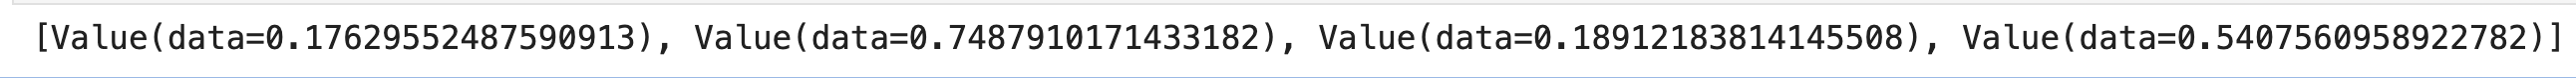

According to the output above (will be different because of randomness), we want:
Oth: become larger (to become 1)
1st: become smaller (to become -1)
2nd: become smaller (to become -1)
3rd: become larger (to become 1)

Currently, there is no process by which the weights are tuned so that the desired outputs are achieved

This is where loss / the loss function comes in:

## Loss:
- a single number by which we measure the performance of our neural network
- we would want to minimize the loss
- we use the "means square loss" as our loss function
- alternatively, we can also subtract both of them and take their absolute value

Note: Why absolute value of loss and not include sign also:
- We want the definition of loss to be "how far away from being perfect is our model right now"
- To fit loss in this definition, we take the absolute value so wrongness in -ve or positive can be quantified and compared
- This also matters, because for a neural network, we take the sum of all the training data (the 4 values in this case) to see performance
- If in training data, we have one loss to be -2, and other to be +2, total loss will be 0 (not ideal, signifies perfect net but our net isn't perfect. It's the opposite actually) - therefore keep everything in terms of loss positive

### Means Square Loss:
- $MSL = (expected - predicted)^2$

In [156]:
individual_losses = []
for i in range(len(y_pred)):
    predicted = y_pred[i]
    ground_truth = ys[i]
    individual_losses.append((ground_truth - predicted) ** 2)

loss = sum(individual_losses)

# We want to now minimize this loss and make it as close to 0 as possible (close to 0 = better model)
loss 

Value(data=6.095040005696189)

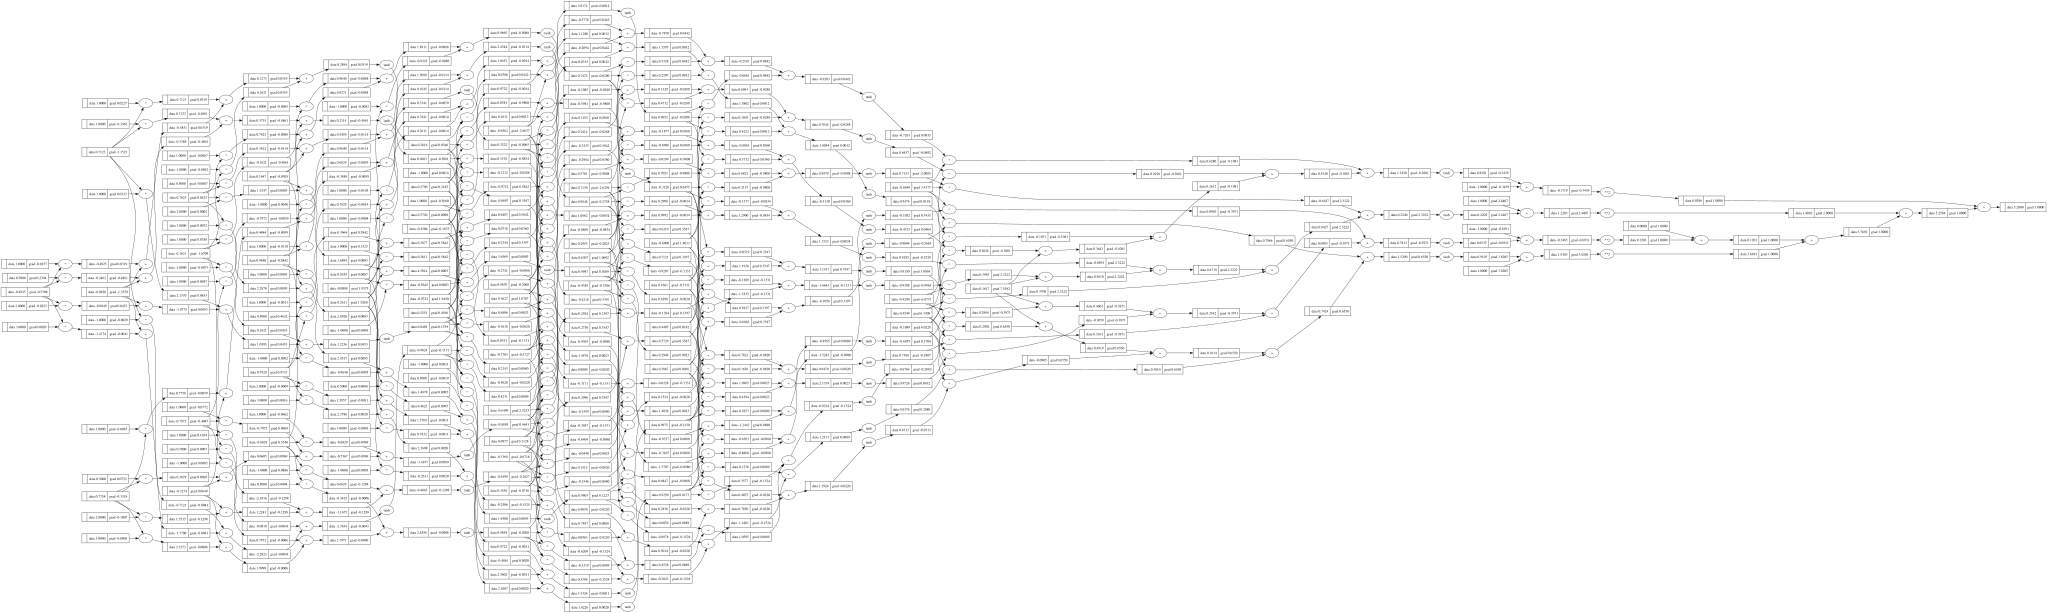

In [165]:
loss.backward() # backward pass for the entire neural net till the first layer (input layer)
MicrogradGraph().draw_dot(loss) # big ahh graph of the entire MLP

In [158]:
# even though it calcs the gradients for the input layer, we 
# won't be concerned with that, and be concerned w all other layers
# since we don't have control over the input being passed

In [159]:
print("first layer first neuron grad", n.layers[1].neurons[0].weights[0].grad)
print("first layer first neuron data", n.layers[1].neurons[0].weights[0].data)

first layer first neuron grad 0.1326821703164539
first layer first neuron data 0.2593038335900997


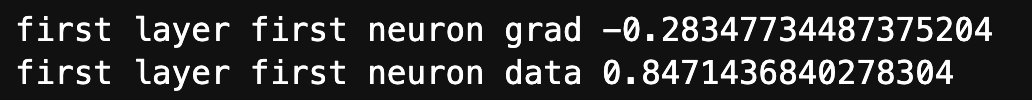

this means: increasing the value of this neuron will decrease the loss (we want ts)

In [166]:
for p in n.parameters():
    # gradient descent: we are modifying (making a tiny update) to the p.data
    # in the direction of the gradient based on the sign of the gradient
    # (negative gradient: increase it; positive gradient: decrease it)
    p.data += -0.01 * p.grad # neg in the learning rate handles the direction
    
print("first layer first neuron grad", n.layers[1].neurons[0].weights[0].grad)
print("first layer first neuron new data", n.layers[1].neurons[0].weights[0].data)

# note: we like to keep the learning rate low because fear of overstepping (destabilize training)
# too low: takes too long to converge; too big: you can blow up your shi and it not converging
# so, setting of learning rate is like an art lol

first layer first neuron grad 0.49162668868566917
first layer first neuron new data 0.2502052947196677


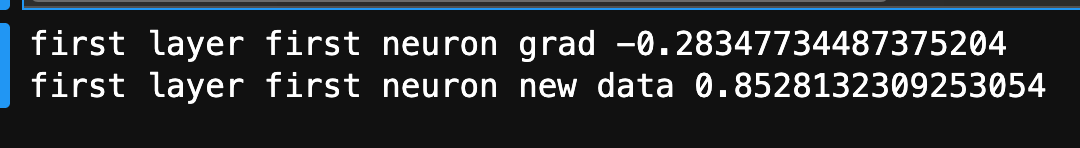

- we nudged the value of this neuron upwards a tiny bit, making it so that it contributes to making the loss lesser

- and not just this neuron, but all of the neurons in the MLP now are changed to make the loss lesser, which is:

In [167]:
y_pred = [n(x) for x in xs]
loss = sum((y_out - y_gt) ** 2 for y_out, y_gt in zip(y_pred, ys))
loss

Value(data=4.641244913792712)

In [168]:
# now, all we have to do is iterate this process:
# 1. do forward pass using n(x),
# 1.5 clear out all the gradients for backward pass to recalculate them again
# 2. do a backward pass using .bockward() on loss
# 3. nudge parameters to make loss lower
# 4. repeat everything starting step 1